<a href="https://colab.research.google.com/github/youjung1111/face-aging-morphing/blob/main/%EC%8B%A4%EC%A2%85%EC%95%84%EB%8F%99GUI(1)_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytorch_lightning



  Using cached pytorch_lightning-2.5.1.post0-py3-none-any.whl.metadata (20 kB)
  Using cached torchmetrics-1.7.3-py3-none-any.whl.metadata (21 kB)
  Using cached lightning_utilities-0.14.3-py3-none-any.whl.metadata (5.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)


In [ ]:
#0..ckpt file-->.pth file(model1 checkpoint file 변환)
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/best-model2.ckpt의 사본"
import torch
from collections import OrderedDict

# 📥 1. ckpt 파일 로드
ckpt_path = "/content/drive/MyDrive/best-model2.ckpt의 사본"
ckpt = torch.load(ckpt_path, map_location='cpu')
# 🧠 2. state_dict 추출
if 'state_dict' in ckpt:
    state_dict = ckpt['state_dict']
else:
    state_dict = ckpt  # 혹시 Lightning 아닌 경우

# 🧹 3. 키 앞에 붙은 'model.' 같은 접두사 제거
cleaned_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_k = k.replace("model.", "") if k.startswith("model.") else k
    cleaned_state_dict[new_k] = v

# 💾 4. 저장
torch.save(cleaned_state_dict, "/content/converted_model.pth")
print("✅ 변환 완료: /content/converted_model.pth")

!ls "/content/drive/MyDrive/best-model2.ckpt의 사본"





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/best-model2.ckpt의 사본'
✅ 변환 완료: /content/converted_model.pth
'/content/drive/MyDrive/best-model2.ckpt의 사본'


In [ ]:
# 0(2): Fast-AgingGAN & MorphGAN 전체 레포 클론
#!git clone https://github.com/youjung1111/face-aging-morphing/tree/main/aging_model
#!git clone https://github.com/youjung1111/face-aging-morphing/tree/main/morphing_model


!git clone https://github.com/youjung1111/face-aging-morphing


# PyTorch, Pillow, 기타 패키지 설치
!pip install -r Fast-AgingGAN/requirements.txt
!pip install -r MorphGAN/requirements.txt
!pip install torch torchvision matplotlib Pillow

# 기타 경로 정리
import os
os.makedirs("input", exist_ok=True)
os.makedirs("processed", exist_ok=True)



# ✅ [MorphGAN 체크포인트 첨부 코드]
from google.colab import drive
drive.mount('/content/drive')  # 처음 한 번만 실행

!mkdir -p Fast-AgingGAN/pretrained_model
!cp /content/converted_model.pth Fast-AgingGAN/pretrained_model/latest_net_G.pth

# checkpoint를 MorphGAN이 찾는 경로로 복사
# 1. 체크포인트를 MorphGAN 내부의 지정된 위치로 복사
!mkdir -p MorphGAN/checkpoints/final_deep1_256_final_deep1

!cp /content/drive/MyDrive/latest_net_G.pth MorphGAN/checkpoints/final_deep1_256_final_deep1/



fatal: destination path 'face-aging-morphing' already exists and is not an empty directory.
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'Fast-AgingGAN/requirements.txt'
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'MorphGAN/requirements.txt'
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#[과정1]: 사용자 파일 업로드 및 입력



from google.colab import files
from PIL import Image
import IPython.display as display
import os

# ✅ input 폴더 먼저 생성
os.makedirs("input", exist_ok=True)


# 아동 사진
print("① 실종 당시 아동의 사진(jpg)을 업로드해주세요.")
child = files.upload()
child_path = list(child.keys())[0]

# 엄마 사진
print("② 어머니 사진(jpg)을 업로드해주세요.")
mom = files.upload()
mom_path = list(mom.keys())[0]

# 아빠 사진
print("③ 아버지 사진(jpg)을 업로드해주세요.")
dad = files.upload()
dad_path = list(dad.keys())[0]

# 이미지 저장 및 변환
for name in [child_path, mom_path, dad_path]:
    img = Image.open(name).convert("RGB").resize((256, 256))
    img.save(f"input/{name}")


① 실종 당시 아동의 사진(jpg)을 업로드해주세요.


In [ ]:
#[과정1_4]: 기타 정보 입력
print("④ 실종 아동의 기타 정보를 입력해주세요.")
name = input("1) 아동 이름: ")
age_then = input("2) 당시 나이: ")
age_now = input("3) 현재 나이: ")
desc = input("4) 특징: ")
phone = input("5) 연락처 (010-0000-0000): ")


④ 실종 아동의 기타 정보를 입력해주세요.
1) 아동 이름: 난아동
2) 당시 나이: 8
3) 현재 나이: 45
4) 특징: 눈에 점
5) 연락처 (010-0000-0000): 010-0000-0000


In [ ]:
# (E) aging_model로 이동 후 infer.py 덮어쓰기
%cd face-aging-morphing/aging_model

new_code = '''
import os
from argparse import ArgumentParser
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms
from gan_module import Generator

parser = ArgumentParser()
parser.add_argument('--image_dir', default='.', help='The image directory')

@torch.no_grad()
def main():
    args = parser.parse_args()
    image_paths = [os.path.join(args.image_dir, x) for x in os.listdir(args.image_dir) if x.endswith('.png') or x.endswith('.jpg')]
    if not image_paths:
        print("❌ No input images found.")
        return
    model = Generator(ngf=32, n_residual_blocks=9)
    ckpt = torch.load('pretrained_model/state_dict.pth', map_location='cpu')
    model.load_state_dict(ckpt)
    model.eval()
    trans = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ])
    img = Image.open(image_paths[0]).convert('RGB')
    img_tensor = trans(img).unsqueeze(0)
    aged_face = model(img_tensor)
    aged_face = (aged_face.squeeze().permute(1, 2, 0).numpy() + 1.0) / 2.0
    os.makedirs("results", exist_ok=True)
    plt.imsave("results/input_aged.jpg", aged_face)
if __name__ == '__main__':
    main()
'''
with open("infer.py", "w") as f:
    f.write(new_code)

print("✅ infer.py successfully rewritten.")


/content/face-aging-morphing/aging_model
✅ infer.py successfully rewritten.


In [ ]:
# input 폴더에 아동 사진이 있다면 실행
import shutil

child_input = f"/content/input/{child_path}"
dst_input = "input.jpg"
shutil.copy(child_input, dst_input)  # aging_model 폴더로 복사

!python infer.py --image_dir .


In [ ]:
import os
print(os.path.exists('results/input_aged.jpg'))  # True가 나와야 함


True


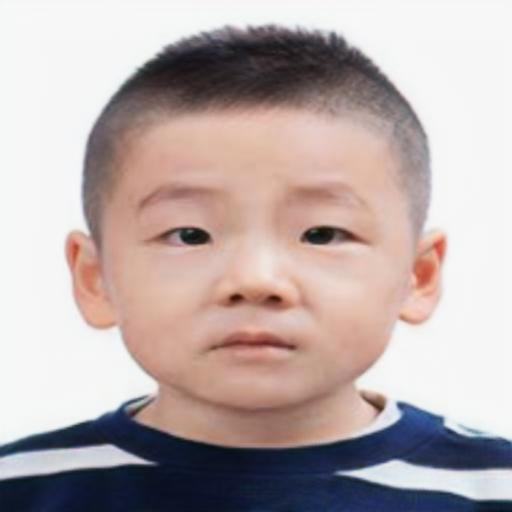

In [ ]:
from IPython.display import Image as ShowImage
ShowImage(filename='results/input_aged.jpg')



In [ ]:
%cd /content

/content


In [ ]:
import os
print(os.listdir("/content/input"))
print(mom_path)  # 실제 변수 값 확인

['test1.jpg', 'test1_mom.jpg', 'test1_dad.jpg']
test1_mom.jpg


In [ ]:
!pip install dominate

In [ ]:
!pip install visdom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=f52b5ec67a8a04ba63a1a3bc62e13ecf8a212673a588bcf76f8735a2cd6538e7
  Stored in directory: /root/.cache/pip/wheels/fa/a4/bb/2be445c295d88a74f9c0a4232f04860ca489a5c7c57eb959d9
Successfully built visdom


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/MorphGAN/checkpoints_backup/mom_dad", exist_ok=True)

In [ ]:
# 실제로 폴더가 있는지 확인
import os

folder = "/content/drive/MyDrive/MorphGAN/checkpoints_backup/"
os.makedirs(folder, exist_ok=True)  # 폴더가 없으면 생성

# 임시 파일 생성 테스트
test_file = os.path.join(folder, "temp_write_test.txt")
try:
    with open(test_file, "w") as f:
        f.write("Colab에서 쓰기 권한 테스트")
    print("✅ 쓰기 성공! 파일 생성됨:", test_file)
    os.remove(test_file)  # 테스트 파일 삭제
except Exception as e:
    print("❌ 쓰기 실패:", e)


✅ 쓰기 성공! 파일 생성됨: /content/drive/MyDrive/MorphGAN/checkpoints_backup/temp_write_test.txt


In [ ]:
import os

folder = "/content/face-aging-morphing/datasets/mom_dad"
print("mom_dad 폴더 내 파일:", os.listdir(folder))
print("pairs.txt 내용:")
with open(os.path.join(folder, "pairs.txt")) as f:
    print(f.read())


mom_dad 폴더 내 파일: ['A.jpg', 'pairs.txt', 'B.jpg']
pairs.txt 내용:
A.jpg B.jpg


In [ ]:
from PIL import Image

for fname in ["A.jpg", "B.jpg"]:
    try:
        img = Image.open(os.path.join(folder, fname))
        img.verify()  # 이미지가 정상적으로 열리면 아무런 에러도 안 남
        print(f"✅ {fname} 정상 이미지")
    except Exception as e:
        print(f"❌ {fname} 에러: {e}")


✅ A.jpg 정상 이미지
✅ B.jpg 정상 이미지


In [ ]:
import os
print("CWD:", os.getcwd())
folder = "/content/face-aging-morphing/datasets/mom_dad"
print("mom_dad 폴더 파일:", os.listdir(folder))


CWD: /content/face-aging-morphing/morphing_model
mom_dad 폴더 파일: ['A.jpg', 'pairs.txt', 'B.jpg']


In [ ]:
with open(os.path.join(folder, "pairs.txt")) as f:
    print("pairs.txt 내용:", f.read())


pairs.txt 내용: A.jpg B.jpg


In [ ]:
from PIL import Image
for name in ["A.jpg", "B.jpg"]:
    try:
        Image.open(os.path.join(folder, name)).verify()
        print(name, "정상")
    except Exception as e:
        print(name, "에러:", e)


A.jpg 정상
B.jpg 정상


In [ ]:
import os
print("현재 작업 디렉토리:", os.getcwd)

현재 작업 디렉토리: <built-in function getcwd>


In [ ]:
# runt.sh에서 -d ../datasets/mom_dad 로 주는 경우 실제 경로 확인
dataroot = os.path.abspath("../datasets/mom_dad")
print("dataroot 실제 경로:", dataroot)
print("dataroot 파일 목록:", os.listdir(dataroot))


dataroot 실제 경로: /content/face-aging-morphing/datasets/mom_dad
dataroot 파일 목록: ['A.jpg', 'pairs.txt', 'B.jpg']


In [ ]:
pairs_txt = os.path.join(dataroot, "pairs.txt")
with open(pairs_txt, "r") as f:
    print("pairs.txt 내용:", f.read())

for fname in ["A.jpg", "B.jpg"]:
    fpath = os.path.join(dataroot, fname)
    print(f"{fname} 존재? {os.path.isfile(fpath)}")


pairs.txt 내용: A.jpg B.jpg
A.jpg 존재? True
B.jpg 존재? True


In [ ]:
with open(os.path.join(folder, "pairs.txt"), "r") as f:
    print(f.read())


A.jpg B.jpg


In [ ]:
folder = os.path.abspath("../datasets/mom_dad")
for fname in os.listdir(folder):
    print(fname, os.path.getsize(os.path.join(folder, fname)), "bytes")


A.jpg 9911 bytes
pairs.txt 11 bytes
B.jpg 9329 bytes


In [ ]:
from PIL import Image
for fname in ["A.jpg", "B.jpg"]:
    try:
        img = Image.open(os.path.join(dataroot, fname))
        img.verify()
        print(fname, "정상적으로 열림")
    except Exception as e:
        print(fname, "열기 실패:", e)


A.jpg 정상적으로 열림
B.jpg 정상적으로 열림


In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/latest_net_G.pth'))
print(os.listdir('/content/drive/MyDrive/MorphGAN/checkpoints_backup/'))
print(os.listdir('/content/drive/MyDrive/MorphGAN/checkpoints_backup/mom_dad/'))


True
['mom_dad']
['opt_1.txt', 'opt_2.txt', 'opt_3.txt', 'opt_4.txt', 'opt_5.txt', 'opt_6.txt', 'opt_7.txt', 'opt_8.txt', 'opt_9.txt', 'opt_10.txt', 'opt_11.txt']


In [ ]:
import shutil
src = '/content/drive/MyDrive/latest_net_G.pth'
dst = '/content/drive/MyDrive/MorphGAN/checkpoints_backup/mom_dad/latest_net_G.pth'
os.makedirs('/content/drive/MyDrive/MorphGAN/checkpoints_backup/mom_dad', exist_ok=True)
shutil.copy(src, dst)


'/content/drive/MyDrive/MorphGAN/checkpoints_backup/mom_dad/latest_net_G.pth'

In [ ]:
# # 1. 데이터 준비 (mom_dad)
# import os, shutil
# os.makedirs("/content/face-aging-morphing/datasets/mom_dad", exist_ok=True)
# shutil.copy("/content/input/test1_mom.jpg", "/content/face-aging-morphing/datasets/mom_dad/A.jpg")
# shutil.copy("/content/input/test1_dad.jpg", "/content/face-aging-morphing/datasets/mom_dad/B.jpg")
# with open("/content/face-aging-morphing/datasets/mom_dad/pairs.txt", "w") as f:
#     f.write("A.jpg B.jpg")
import os, shutil

dst = "/content/face-aging-morphing/datasets/mom_dad"
os.makedirs(dst, exist_ok=True)

# mom_path, dad_path 변수는 파일명(예: test1_mom.jpg)이어야 함!
shutil.copy(f"/content/input//test1_mom.jpg", os.path.join(dst, "test1_A.jpg"))
shutil.copy(f"/content/input//test1_dad.jpg", os.path.join(dst, "test1_B.jpg"))

with open(os.path.join(dst, "pairs.txt"), "w") as f:
    f.write("test1_A.jpg test1_B.jpg")



# 2. 실행권한 부여
!./runt.sh -n mom_dad -v mom_dad -t -s 256 -d ../datasets/mom_dad

!chmod +x /content/face-aging-morphing/morphing_model/runt.sh

# 3. runt.sh 실행 (필수 옵션 명시!)
!cd /content/face-aging-morphing/morphing_model && \
  ./runt.sh -n mom_dad -d ../datasets/mom_dad -v mom_dad  -s 256



test.py --dataroot ../datasets/mom_dad --name mom_dad --save_dir mom_dad --checkpoints_dir /content/drive/MyDrive/MorphGAN/checkpoints_backup --model dmorph --fineSize 256 --nintrm 5 --batchSize 1 --dataset_mode aligned --phase test --stn
----------------- Options ---------------
             aspect_ratio: 1.0                           
                batchSize: 1                             
          checkpoints_dir: /content/drive/MyDrive/MorphGAN/checkpoints_backup	[default: ./checkpoints/]
                    costl: False                         
                 dataroot: ../datasets/mom_dad           	[default: None]
             dataset_mode: aligned                       	[default: unaligned]
               display_id: 1                             
             display_port: 8097                          
           display_server: http://localhost              
          display_winsize: 256                           
                 fineSize: 256                          

In [ ]:
from IPython.display import Image as ShowImage
ShowImage(filename='results/input_aged.jpg')

In [ ]:
import os, shutil

# 경로 정의
morph_dataset = "/content/face-aging-morphing/datasets/final_blend"
os.makedirs(morph_dataset, exist_ok=True)

# 모델1 결과(아동+aging) → A
shutil.copy("/content/face-aging-morphing/aging_model/results/input_aged.jpg",
            os.path.join(morph_dataset, "test1_A.jpg"))

# 부모 블렌딩 결과(예: mom_dad/fake_B/test1_A.jpg 등 MorphGAN 출력 위치에 따라 다름)
# 보통 MorphGAN 결과물 폴더 내에 있음 (아래 예시는 대표 경로, 실제 경로 다를 수 있음)
parent_blend_path = "/content/face-aging-morphing/morphing_model/mom_dad/fake_B/test1_A.jpg"
if not os.path.exists(parent_blend_path):
    # 보통 결과가 mom_dad/results 또는 results/mom_dad/ 등의 다른 경로에 있을 수 있음
    import glob
    candidates = glob.glob("/content/face-aging-morphing/**/test1_B.jpg", recursive=True)
    if candidates:
        parent_blend_path = candidates[0]
    else:
        raise FileNotFoundError("부모 블렌딩 결과(test1_B.jpg)를 찾을 수 없습니다!")

shutil.copy(parent_blend_path, os.path.join(morph_dataset, "test1_B.jpg"))

# pairs.txt 생성
with open(os.path.join(morph_dataset, "pairs.txt"), "w") as f:
    f.write("test1_A.jpg test1_B.jpg")


In [ ]:
import os

os.makedirs('/content/drive/MyDrive/MorphGAN/checkpoints_backup/final_blend', exist_ok=True)


In [ ]:
import shutil
src = '/content/drive/MyDrive/MorphGAN/checkpoints_backup/mom_dad/latest_net_G.pth'  # 기존 체크포인트 경로
dst = '/content/drive/MyDrive/MorphGAN/checkpoints_backup/final_blend/latest_net_G.pth'  # 새 경로
shutil.copy(src, dst)


'/content/drive/MyDrive/MorphGAN/checkpoints_backup/final_blend/latest_net_G.pth'

In [ ]:
# morphing_model로 이동
%cd /content/face-aging-morphing/morphing_model

# 실행권한 부여
!chmod +x runt.sh

# 최종 MorphGAN 블렌딩 실행 (이때 -t 옵션은 실제 학습 옵션과 일치시켜야 함! 에러 없었으니 -t 없이 예시)
!./runt.sh -n final_blend -v final_blend -s 256 -d ../datasets/final_blend


/content/face-aging-morphing/morphing_model
test.py --dataroot ../datasets/final_blend --name final_blend --save_dir final_blend --checkpoints_dir /content/drive/MyDrive/MorphGAN/checkpoints_backup --model dmorph --fineSize 256 --nintrm 5 --batchSize 1 --dataset_mode aligned --phase test
----------------- Options ---------------
             aspect_ratio: 1.0                           
                batchSize: 1                             
          checkpoints_dir: /content/drive/MyDrive/MorphGAN/checkpoints_backup	[default: ./checkpoints/]
                    costl: False                         
                 dataroot: ../datasets/final_blend       	[default: None]
             dataset_mode: aligned                       	[default: unaligned]
               display_id: 1                             
             display_port: 8097                          
           display_server: http://localhost              
          display_winsize: 256                           
      

In [ ]:
# # 1. morphing_model 폴더로 이동
# %cd /content/face-aging-morphing/morphing_model

# # 2. mom_dad 데이터셋 준비
# import os, shutil
# os.makedirs("datasets/mom_dad", exist_ok=True)
# shutil.copy("/content/input/test1_mom.jpg", "datasets/mom_dad/A.jpg")
# shutil.copy("/content/input/test1_dad.jpg", "datasets/mom_dad/B.jpg")
# with open("datasets/mom_dad/pairs.txt", "w") as f:
#     f.write("A.jpg B.jpg")

# # 3. 실행권한 부여 (최초 1회)
# !chmod +x runt.sh

# # 4. MorphGAN 실행
# !./runt.sh -n mom_dad -v mom_dad -t -s 256

# # (결과 경로: checkpoints/mom_dad_256_mom_dad/web/images/latest_test/fake_B.png)


In [ ]:
# # 2. 모델2: 엄마 + 아빠 → 블렌딩
# os.makedirs("MorphGAN/datasets/mom_dad", exist_ok=True)
# shutil.copy(f"input/{mom_path}", "MorphGAN/datasets/mom_dad/A.jpg")
# shutil.copy(f"input/{dad_path}", "MorphGAN/datasets/mom_dad/B.jpg")
# with open("MorphGAN/datasets/mom_dad/pairs.txt", "w") as f:
#     f.write("A.jpg B.jpg")

# %cd MorphGAN
# !./runt.sh -n mom_dad -v mom_dad -t -s 256
# %cd ..

# mom_dad_blend = "MorphGAN/checkpoints/mom_dad_256_mom_dad/web/images/latest_test/fake_B.png"

# 3. 모델2: aged_child + mom_dad_blend → 최종 블렌딩
# os.makedirs("MorphGAN/datasets/final", exist_ok=True)

# Ensure aged_child path is correct before copying
# The aged_child variable already holds the correct path relative to the notebook's working directory
# shutil.copy(aged_child, "MorphGAN/datasets/final/A.jpg")
# shutil.copy(mom_dad_blend, "MorphGAN/datasets/final/B.jpg")
# with open("MorphGAN/datasets/final/pairs.txt", "w") as f:
#     f.write("A.jpg B.jpg")

# %cd MorphGAN
# !./runt.sh -n final_blend -v final_blend  -s 256
# %cd ..

# final_blend = "MorphGAN/checkpoints/final_blend_256_final_blend/web/images/latest_test/fake_B.png"

NameError: name 'aged_child' is not defined

## 한글 네모로 안깨지게 셀 43,44 둘다 test후 gui output final 셀 실행

In [ ]:

# 🟩 한글 폰트 설치
!apt-get -qq install fonts-nanum

# 🟩 런타임이 인식할 수 있도록 강제로 reload
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 경로 확인 및 등록
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)

for f in font_files:
    fm.fontManager.addfont(f)

# 기본 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'


Selecting previously unselected package fonts-nanum.
(Reading database ... 126319 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


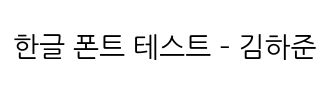

In [ ]:
# 🟡 확인용 출력
plt.figure(figsize=(4, 1))
plt.text(0.5, 0.5, '한글 폰트 테스트 – 김하준', ha='center', va='center', fontsize=20)
plt.axis('off')
plt.show()


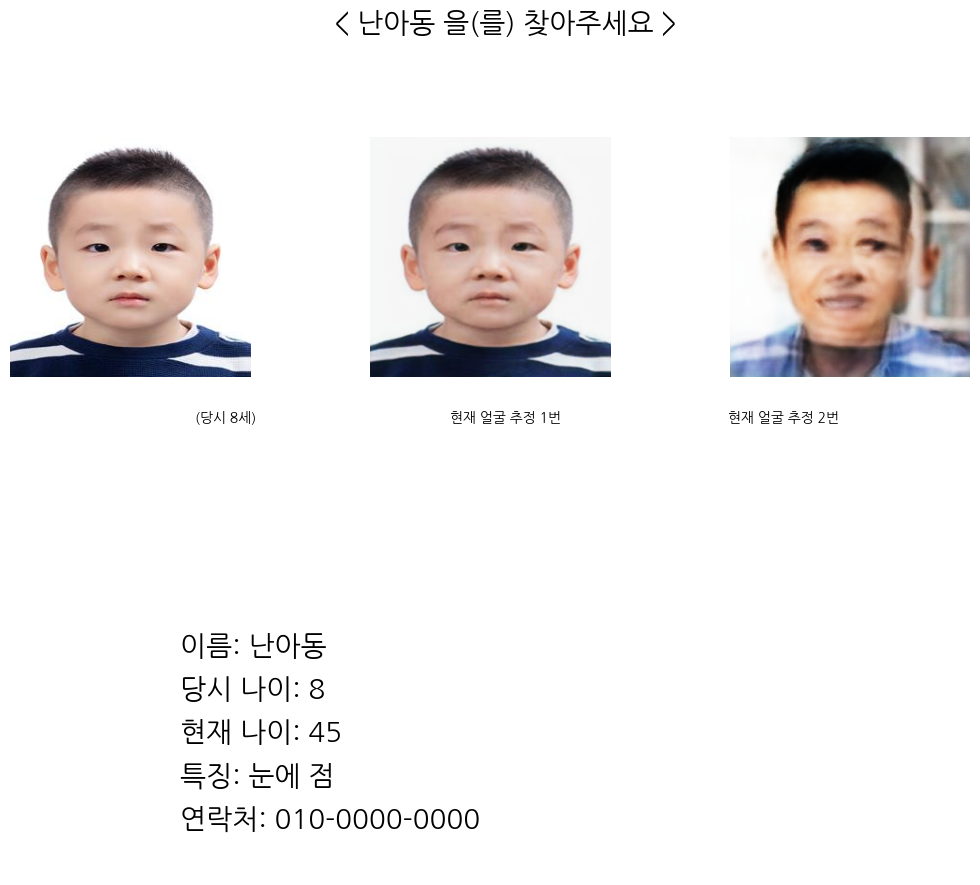

In [ ]:
# # ✅ 나눔폰트 설치
# !apt-get -qq install fonts-nanum
# import matplotlib.font_manager as fm
# import matplotlib.pyplot as plt

# # ✅ 한글 폰트 설정
# plt.rc('font', family='NanumGothic')


#[과정 4] GUI 포스터 출력
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

fig, ax = plt.subplots(figsize=(12, 10))
plt.axis('off')

# 포스터 제목
plt.text(0.5, 1.02, f"< {name} 을(를) 찾아주세요 >", fontsize=20, ha='center', va='bottom', transform=ax.transAxes)


child_path = "/content/input/test1.jpg"#test1.jpg"  # input/child1.jpg가 실제 존재
aged_child =  "/content/face-aging-morphing/aging_model/results/input_aged.jpg"
final_blend = "/content/face-aging-morphing/morphing_model/results/final_blend/test_latest/images/test1_A_intr_1.00.png"
# 이미지 로드
img1 = Image.open(child_path)
img2 = Image.open(aged_child)
img3 = Image.open(final_blend) #-->주석 해제

# 이미지 출력 (수평)
positions = [0.1, 0.4, 0.7]
captions = [f"(당시 {age_then}세)", "현재 얼굴 추정 1번", "현재 얼굴 추정 2번"]
imgs = [img1, img2,img3]

for i in range(3): #원래 range(3)
    ax_img = fig.add_axes([positions[i], 0.55, 0.2, 0.25])
    ax_img.imshow(imgs[i])
    ax_img.axis('off')
    plt.text(positions[i]+0.1, 0.52, captions[i], fontsize=10, ha='center', transform=ax.transAxes)

# 아동 기타 정보
info = f"""
이름: {name}
당시 나이: {age_then}
현재 나이: {age_now}
특징: {desc}
연락처: {phone}
"""
plt.text(0.15, 0.3, info, fontsize=20, ha='left', va='top', transform=ax.transAxes ,linespacing=1.8)

plt.show()


In [1]:
# GitHub 연동을 위한 인증 (최초 1회)
!git config --global user.email "annahpark0812@gmail.com"
!git config --global user.name "anna08-lab"


In [2]:
!git clone https://github.com/youjung1111/face-aging-morphing


Cloning into 'face-aging-morphing'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 350 (delta 25), reused 0 (delta 0), pack-reused 277 (from 3)
Receiving objects: 100% (350/350), 10.29 MiB | 15.43 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [4]:
%cd /content/pipeline_poster_ui
# 예: 새 코드 파일 만들기
with open("demo_pipeline_poster.ipynb", "w") as f:
    f.write("# Your content here")


[Errno 2] No such file or directory: '/content/pipeline_poster_ui'
/content
